# Stock Price Prediction with PyTorch — LSTM vs GRU

## 1. Imports and configuration

This notebook uses Yahoo Finance through `yfinance` for the historical stock dataset. The default example is Amazon (AMZN) matching the project plan's example.
The experiment uses a chronological train/test split because this is time series data. **The scaler is fitted only on the training portion** to avoid test data leakage.


In [ ]:
# If needed install dependencies in your environment before running:
# pip install yfinance pandas numpy matplotlib scikit-learn torch

import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

TICKER = "AMZN"
YEARS = 10
LOOKBACK = 20
TRAIN_RATIO = 0.80

HIDDEN_SIZE = 32
NUM_LAYERS = 2
DROPOUT = 0.20
EPOCHS = 50
LEARNING_RATE = 0.001

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch:", torch.__version__)
print("Device:", DEVICE)
print("Ticker:", TICKER)


PyTorch: 2.12.0
Device: cpu
Ticker: AMZN


## 2. Load historical stock data

In [ ]:
end_date = pd.Timestamp.today().normalize()
start_date = end_date - pd.DateOffset(years=YEARS)

data = yf.download(
    TICKER,
    start=start_date.strftime("%Y-%m-%d"),
    end=(end_date + pd.Timedelta(days=1)).strftime("%Y-%m-%d"),
    progress=False,
    auto_adjust=True,
    threads=False
)

if data.empty:
    raise RuntimeError(
        f"No real Yahoo Finance data was returned for {TICKER}. "
        "Check your internet connection/ticker and rerun the notebook."
    )


if isinstance(data.columns, pd.MultiIndex):
    if ("Close", TICKER) in data.columns:
        close = data[("Close", TICKER)]
    else:
        close = data["Close"].iloc[:, 0]
else:
    close = data["Close"]

close = close.dropna().astype(float)
close.name = "Close"

if len(close) < 100:
    raise RuntimeError("Too few observations were downloaded for a meaningful experiment.")

print(f"Downloaded {len(close):,} daily observations.")
print(f"Period: {close.index.min().date()} to {close.index.max().date()}")
close.head()


Downloaded 2,514 daily observations.
Period: 2016-08-15 to 2026-08-14


Date
2016-08-15    38.424500
2016-08-16    38.202000
2016-08-17    38.231499
2016-08-18    38.223000
2016-08-19    37.865501
Name: Close, dtype: float64

## 3. Exploratory data analysis

The project plan asks for basic exploration and a closing-price visualization. We also inspect descriptive statistics and missing values.


In [8]:
print("Descriptive statistics:")
display(close.describe().to_frame())

print("Missing values:", close.isna().sum())
print("Number of observations:", len(close))


Descriptive statistics:


,Close
count,2514.000000
mean,133.316151
std,59.955023
min,35.953499
25%,87.910753
50%,129.395004
75%,175.143246
max,284.019989


Missing values: 0
Number of observations: 2514


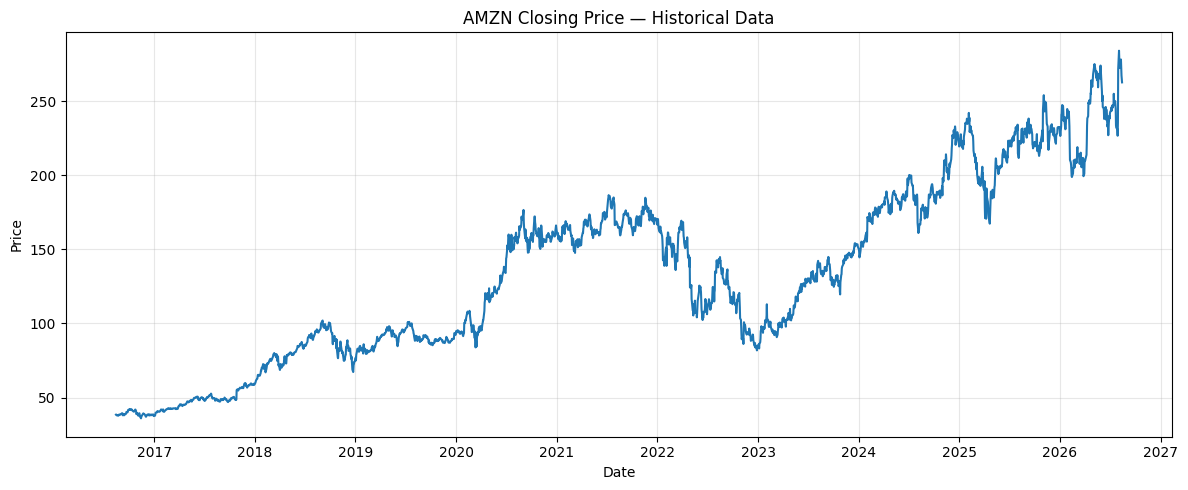

In [9]:
plt.figure(figsize=(12, 5))
plt.plot(close.index, close.values)
plt.title(f"{TICKER} Closing Price — Historical Data")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 4. Train/test split

For a time series, the split is chronological:

- first 80% → training data
- final 20% → unseen test data

No future observations are used to train the model.

The scaler is fitted **only on the training prices**, which prevents information from the test period from influencing preprocessing.


In [ ]:
split_idx = int(len(close) * TRAIN_RATIO)

train_prices = close.iloc[:split_idx].to_numpy().reshape(-1, 1)
test_prices = close.iloc[split_idx:].to_numpy().reshape(-1, 1)

scaler = MinMaxScaler(feature_range=(-1, 1))
train_scaled = scaler.fit_transform(train_prices)


test_scaled = scaler.transform(test_prices)

print("Training observations:", len(train_prices))
print("Test observations:", len(test_prices))

print(
    "Training period:",
    close.index[0].date(),
    "to",
    close.index[split_idx - 1].date()
)

print(
    "Test period:",
    close.index[split_idx].date(),
    "to",
    close.index[-1].date()
)


Training observations: 2011
Test observations: 503
Training period: 2016-08-15 to 2024-08-12
Test period: 2024-08-13 to 2026-08-14


## 5. Create sliding-window sequences

The model receives the previous `LOOKBACK` trading days and predicts the next trading day's closing price.

For example, with a lookback of 20:

`days 1–20 → predict day 21`

`days 2–21 → predict day 22`

and so on.


In [ ]:
def create_sequences(values, lookback):
    X, y = [], []
    for i in range(lookback, len(values)):
        X.append(values[i - lookback:i])
        y.append(values[i])
    return np.asarray(X, dtype=np.float32), np.asarray(y, dtype=np.float32).reshape(-1, 1)

X_train_np, y_train_np = create_sequences(train_scaled, LOOKBACK)

combined_for_test = np.vstack([train_scaled[-LOOKBACK:], test_scaled])
X_test_np, y_test_np = create_sequences(combined_for_test, LOOKBACK)

print("X_train:", X_train_np.shape)
print("y_train:", y_train_np.shape)
print("X_test:", X_test_np.shape)
print("y_test:", y_test_np.shape)


X_train: (1991, 20, 1)
y_train: (1991, 1)
X_test: (503, 20, 1)
y_test: (503, 1)


## 6. Convert data to PyTorch tensors

PyTorch models operate on tensors. The LSTM/GRU input shape is:

`[samples, sequence_length, features]`

Here there is one feature: the closing price.


In [12]:
X_train = torch.from_numpy(X_train_np).to(DEVICE)
y_train = torch.from_numpy(y_train_np).to(DEVICE)
X_test = torch.from_numpy(X_test_np).to(DEVICE)
y_test = torch.from_numpy(y_test_np).to(DEVICE)

print("Tensor shapes:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)


Tensor shapes:
X_train: torch.Size([1991, 20, 1])
y_train: torch.Size([1991, 1])
X_test: torch.Size([503, 20, 1])
y_test: torch.Size([503, 1])


## 7. Define the LSTM and GRU models

Both models use the same general architecture and hyperparameters so that their results can be compared fairly.

- input size = 1
- hidden size = 32
- 2 recurrent layers
- dropout = 0.20 between recurrent layers
- output size = 1

The LSTM maintains hidden and cell states, while the GRU uses a simpler gated recurrent structure.


In [14]:
class LSTMModel(nn.Module):
    def __init__(
        self,
        input_size=1,
        hidden_size=32,
        num_layers=2,
        dropout=0.2,
        output_size=1
    ):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        output, (hidden_state, cell_state) = self.lstm(x)
        last_output = output[:, -1, :]
        return self.fc(last_output)


class GRUModel(nn.Module):
    def __init__(
        self,
        input_size=1,
        hidden_size=32,
        num_layers=2,
        dropout=0.2,
        output_size=1
    ):
        super().__init__()

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        output, hidden_state = self.gru(x)
        last_output = output[:, -1, :]
        return self.fc(last_output)
# Quick shape check
with torch.no_grad():
    test_batch = X_train[:2]
    lstm_check = LSTMModel(
        input_size=1, hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS,
        dropout=DROPOUT, output_size=1
    ).to(DEVICE)
    gru_check = GRUModel(
        input_size=1, hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS,
        dropout=DROPOUT, output_size=1
    ).to(DEVICE)

    print("LSTM output shape:", lstm_check(test_batch).shape)
    print("GRU output shape:", gru_check(test_batch).shape)


LSTM output shape: torch.Size([2, 1])
GRU output shape: torch.Size([2, 1])


## 8. Training function

The training loop uses:

- Mean Squared Error (`nn.MSELoss`) as the regression loss
- Adam as the optimizer
- forward pass
- loss calculation
- backpropagation
- optimizer update

Training loss is recorded so that convergence can be inspected.


In [15]:
def train_model(model, X, y, epochs=50, learning_rate=0.001):
    model = model.to(DEVICE)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    losses = []
    start = time.perf_counter()

    model.train()
    for epoch in range(epochs):
        optimizer.zero_grad()

        predictions = model(X)
        loss = criterion(predictions, y)

        loss.backward()
        optimizer.step()

        losses.append(loss.item())

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoch {epoch + 1:3d}/{epochs} | Training MSE: {loss.item():.6f}")

    elapsed = time.perf_counter() - start
    return model, losses, elapsed


## 9. Train the LSTM


In [16]:
torch.manual_seed(SEED)

lstm_model = LSTMModel(
    input_size=1,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    output_size=1
).to(DEVICE)

lstm_model, lstm_losses, lstm_time = train_model(
    lstm_model, X_train, y_train,
    epochs=EPOCHS,
    learning_rate=LEARNING_RATE
)

print(f"LSTM training time: {lstm_time:.2f} seconds")


Epoch   1/50 | Training MSE: 0.303735
Epoch  10/50 | Training MSE: 0.265154
Epoch  20/50 | Training MSE: 0.202818
Epoch  30/50 | Training MSE: 0.048688
Epoch  40/50 | Training MSE: 0.028768
Epoch  50/50 | Training MSE: 0.010617
LSTM training time: 5.83 seconds


## 10. Train the GRU


In [17]:
torch.manual_seed(SEED)

gru_model = GRUModel(
    input_size=1,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    output_size=1
).to(DEVICE)

gru_model, gru_losses, gru_time = train_model(
    gru_model, X_train, y_train,
    epochs=EPOCHS,
    learning_rate=LEARNING_RATE
)

print(f"GRU training time: {gru_time:.2f} seconds")


Epoch   1/50 | Training MSE: 0.283990
Epoch  10/50 | Training MSE: 0.180130
Epoch  20/50 | Training MSE: 0.053891
Epoch  30/50 | Training MSE: 0.017040
Epoch  40/50 | Training MSE: 0.004191
Epoch  50/50 | Training MSE: 0.006420
GRU training time: 4.19 seconds


## 11. Compare training loss

The training-loss curves help identify whether the models learned during training and whether the loss generally decreased.


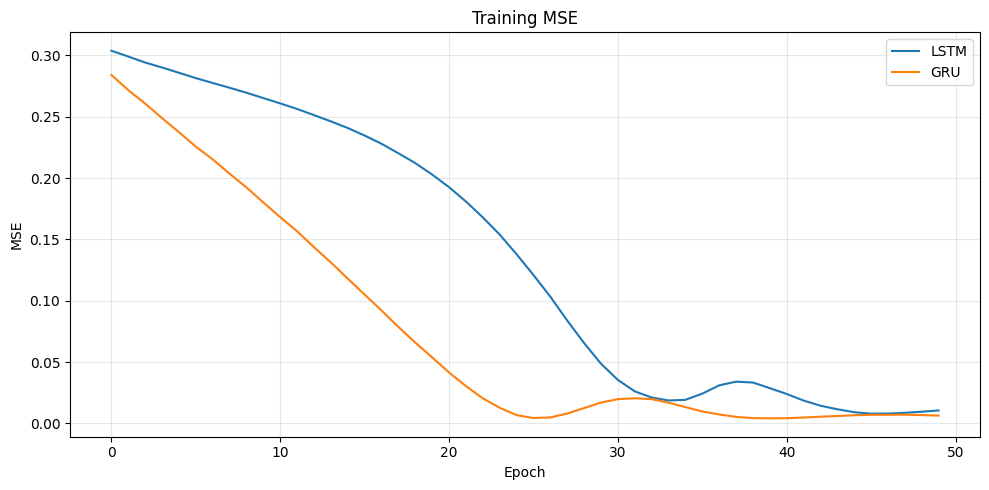

In [18]:
plt.figure(figsize=(10, 5))
plt.plot(lstm_losses, label="LSTM")
plt.plot(gru_losses, label="GRU")
plt.title("Training MSE")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 12. Evaluate on unseen test data

Predictions are generated only for the test set.

MSE and RMSE are calculated after converting predictions back to the original price scale, making RMSE interpretable in the same units as the stock price.


In [24]:
def predict_model(model, X):
    model.eval()
    with torch.no_grad():
        return model(X).detach().cpu().numpy()

lstm_pred_scaled = predict_model(lstm_model, X_test)
gru_pred_scaled = predict_model(gru_model, X_test)

y_test_original = scaler.inverse_transform(y_test_np)
lstm_pred_original = scaler.inverse_transform(lstm_pred_scaled)
gru_pred_original = scaler.inverse_transform(gru_pred_scaled)

lstm_mse = mean_squared_error(y_test_original, lstm_pred_original)
gru_mse = mean_squared_error(y_test_original, gru_pred_original)

lstm_rmse = np.sqrt(lstm_mse)
gru_rmse = np.sqrt(gru_mse)

print(f"LSTM MSE:  {lstm_mse:.4f}")
print(f"LSTM RMSE: {lstm_rmse:.4f}")
print(f"GRU MSE:   {gru_mse:.4f}")
print(f"GRU RMSE:  {gru_rmse:.4f}")


LSTM MSE:  2087.7620
LSTM RMSE: 45.6920
GRU MSE:   537.7048
GRU RMSE:  23.1885


## 13. Actual vs predicted prices

The plots compare the actual unseen test prices with each model's predictions. This provides a visual complement to the numerical MSE/RMSE metrics.


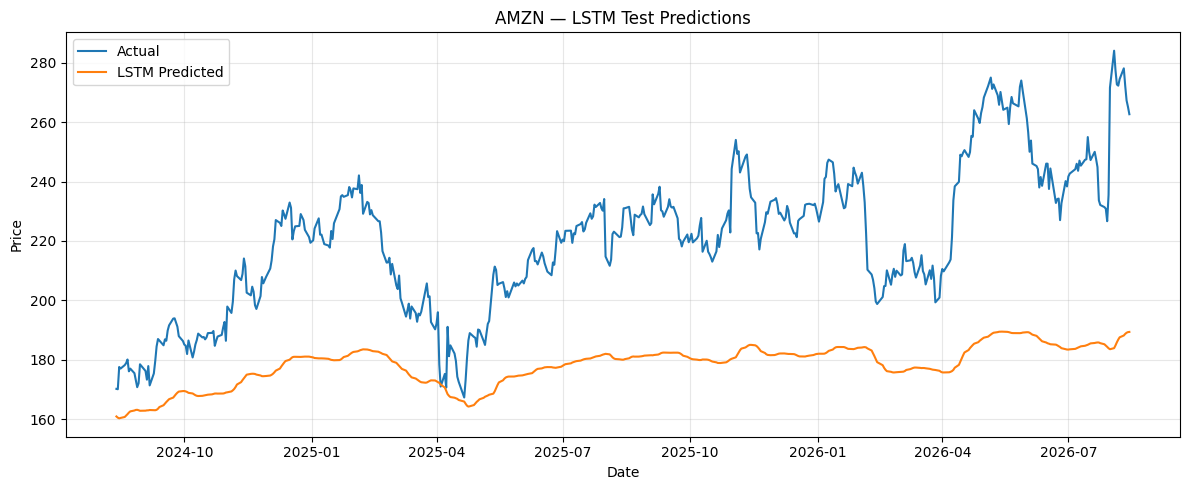

In [ ]:
test_dates = close.index[split_idx:]
assert len(test_dates) == len(y_test_original)

plt.figure(figsize=(12, 5))
plt.plot(test_dates, y_test_original.ravel(), label="Actual")
plt.plot(test_dates, lstm_pred_original.ravel(), label="LSTM Predicted")
plt.title(f"{TICKER} — LSTM Test Predictions")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


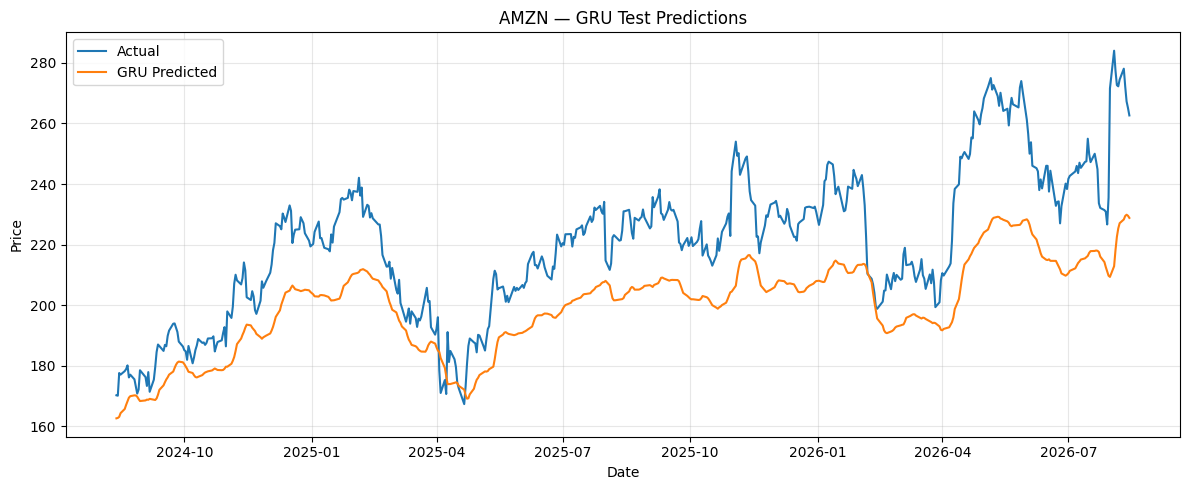

In [21]:
plt.figure(figsize=(12, 5))
plt.plot(test_dates, y_test_original.ravel(), label="Actual")
plt.plot(test_dates, gru_pred_original.ravel(), label="GRU Predicted")
plt.title(f"{TICKER} — GRU Test Predictions")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 14. LSTM vs GRU comparison



In [22]:
results = pd.DataFrame({
    "Model": ["LSTM", "GRU"],
    "MSE": [lstm_mse, gru_mse],
    "RMSE": [lstm_rmse, gru_rmse],
    "Training Time (seconds)": [lstm_time, gru_time]
})

display(results)

best_model = results.loc[results["RMSE"].idxmin(), "Model"]
fastest_model = results.loc[results["Training Time (seconds)"].idxmin(), "Model"]

print(f"Lower test RMSE: {best_model}")
print(f"Faster training in this run: {fastest_model}")


,Model,MSE,RMSE,Training Time (seconds)
0,LSTM,2087.761963,45.692034,5.826886
1,GRU,537.704773,23.188462,4.192618


Lower test RMSE: GRU
Faster training in this run: GRU


## 15. Optional moderate hyperparameter experiment



In [ ]:

RUN_TUNING = True

if RUN_TUNING:
    tuning_rows = []

    for lookback in [10, 20]:
        X_tune_train_np, y_tune_train_np = create_sequences(train_scaled, lookback)
        combined_tune = np.vstack([train_scaled[-lookback:], test_scaled])
        X_tune_test_np, y_tune_test_np = create_sequences(combined_tune, lookback)

        X_tune_train = torch.from_numpy(X_tune_train_np).to(DEVICE)
        y_tune_train = torch.from_numpy(y_tune_train_np).to(DEVICE)
        X_tune_test = torch.from_numpy(X_tune_test_np).to(DEVICE)

        torch.manual_seed(SEED)
        tune_model = GRUModel(
            input_size=1,
            hidden_size=HIDDEN_SIZE,
            num_layers=NUM_LAYERS,
            dropout=DROPOUT,
            output_size=1
        ).to(DEVICE)

        tune_model, _, tune_time = train_model(
            tune_model,
            X_tune_train,
            y_tune_train,
            epochs=30,
            learning_rate=LEARNING_RATE
        )

        tune_pred_scaled = predict_model(tune_model, X_tune_test)
        tune_actual = scaler.inverse_transform(y_tune_test_np)
        tune_pred = scaler.inverse_transform(tune_pred_scaled)

        tune_mse = mean_squared_error(tune_actual, tune_pred)
        tune_rmse = np.sqrt(tune_mse)

        tuning_rows.append({
            "Lookback": lookback,
            "GRU Test MSE": tune_mse,
            "GRU Test RMSE": tune_rmse,
            "Training Time (seconds)": tune_time
        })

    tuning_results = pd.DataFrame(tuning_rows)
    display(tuning_results)
else:
    print("Hyperparameter tuning skipped.")


Epoch   1/30 | Training MSE: 0.286286
Epoch  10/30 | Training MSE: 0.183844
Epoch  20/30 | Training MSE: 0.060797
Epoch  30/30 | Training MSE: 0.011318
Epoch   1/30 | Training MSE: 0.283990
Epoch  10/30 | Training MSE: 0.180130
Epoch  20/30 | Training MSE: 0.053891
Epoch  30/30 | Training MSE: 0.017040


,Lookback,GRU Test MSE,GRU Test RMSE,Training Time (seconds)
0,10,109.792061,10.478171,1.341777
1,20,126.729355,11.257413,2.681959
